### 05 - Model Comparison and Final Selection

This notebook compares logisic regression, Random Forest, and histogram gradient boosting using the fixed V2 feature set.

The workflow begins with a 2024 validation comparison, checks V1 against V2 on shared games, and tunes models using expanding temporal validation from 2020-2024.

The selected configuration is then fitted on 2010-2024 and evaluated on 2025. The fitted evaluation model and its feature metadata are saved for use on live predictions on the 2026 season.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import ParameterGrid
from sklearn.calibration import CalibrationDisplay
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score
from sklearn.neural_network import MLPClassifier

In [2]:
MODEL_START_SEASON = 2010
VALIDATION_SEASON = 2024
TEST_SEASON = 2025
RANDOM_STATE = 42

In [3]:
df = pd.read_csv('../data/processed/model_dataset_v2.csv', parse_dates=['gameday'],)

In [4]:
df = (
    df
    .sort_values(['gameday', 'game_id'])
    .reset_index(drop=True)
)
df.shape

(4617, 80)

### Fixed Inputs and Initial Evaluation Split

All three model families use the same 73 inputs: 36 features for each team, plus a neutral-site status input. Vegas betting lines, final scores, and the home win target are excluded from the predictors.

The initial comparison trains on 2010-2023 and validates on 2024. The 2025 season is excluded from the hyperparameter search and is solely for testing.

The saved dataset provides 3,781 training games, 285 validation games, and 284 test games for these periods.

In [5]:
feature_columns = [
    'pregame_off_epa_blended',
    'pregame_off_success_rate_blended',
    'pregame_pass_epa_blended',
    'pregame_rush_epa_blended',
    'pregame_def_epa_allowed_blended',
    'pregame_def_success_rate_allowed_blended',
    'off_epa_last3',
    'off_success_rate_last3',
    'pass_epa_last3',
    'rush_epa_last3',
    'def_epa_allowed_last3',
    'def_success_rate_allowed_last3',
    'off_epa_last5',
    'off_success_rate_last5',
    'pass_epa_last5',
    'rush_epa_last5',
    'def_epa_allowed_last5',
    'def_success_rate_allowed_last5',
    'off_epa_ewm',
    'off_success_rate_ewm',
    'pass_epa_ewm',
    'rush_epa_ewm',
    'def_epa_allowed_ewm',
    'def_success_rate_allowed_ewm',
    'pregame_elo',
    'pregame_sos',
    'rest_days',
    'short_rest',
    'prior_games',
    'pregame_turnovers',
    'pregame_takeaways',
    'pregame_off_sack_rate',
    'pregame_def_sack_rate',
    'pregame_qb_epa',
    'pregame_qb_epa_last5',
    'pregame_qb_success_rate'
]

features = [
    f"{side}_{column}"
    for side in ["home", "away"]
    for column in feature_columns
] + ["neutral_site"]

target = 'home_win'

In [6]:
train = df[df['season'].between(MODEL_START_SEASON, 2023)].copy()
val = df[df['season'] == VALIDATION_SEASON].copy()
test = df[df['season'] == TEST_SEASON].copy()

X_train = train[features]
y_train = train[target]

X_val = val[features]
y_val = val[target]

X_test = test[features]
y_test = test[target]

print('Training Games:', len(train))
print('Validation Games:', len(val))
print('Test Games:', len(test))

Training Games: 3781
Validation Games: 285
Test Games: 284


### Shared Evaluation Function and Naive Baseline

A common evaluation function calculates accuracy, log loss, Brier score, and ROC-AUC for every model. Winner predictions use a home-win probability threshold of 0.5.

Log loss and Brier score evaluate probability quality, while accuracy evaluates the selected winner. ROC-AUC measures ranking performance.

The naive baseline assigns every game the training period home-win rate, providing a reference that does not use matchup information.

In [7]:
def evaluate_probabilities(
        model_name,
        y_true,
        probabilities,
        evaluation_period=None,
):
    predictions = (probabilities >= 0.5).astype(int)

    return {
        'model': model_name,
        'period': evaluation_period,
        'accuracy': accuracy_score(y_true, predictions),
        'log_loss': log_loss(y_true, probabilities),
        'brier_score': brier_score_loss(y_true, probabilities),
        'roc_auc': roc_auc_score(y_true, probabilities),
        }

In [8]:
training_home_win_rate = y_train.mean()

baseline_val_prob = np.full(
    len(y_val),
    training_home_win_rate,
)

baseline_result = evaluate_probabilities(
    model_name='Baseline',
    y_true=y_val,
    probabilities=baseline_val_prob,
    evaluation_period='2024',
)

pd.DataFrame([baseline_result]).head()

,model,period,accuracy,log_loss,brier_score,roc_auc
0,Baseline,2024,0.547368,0.688958,0.247907,0.5


### Candidate Models and Preprocessing

Logistic regression uses median imputation and standardization. Random Forest uses median imputation without scaling. Histogram gradient boosting handles missing values directly and does not require scaling.

Logistic regression provides a linear benchmark. The tree ensembles can capture nonlinear relationships and interactions among features.

All initial models use the same training and validation games. 

In [9]:
logistic_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

In [10]:
random_forest_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

In [11]:
gradient_boosting_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    min_samples_leaf=20,
    l2_regularization=1,
    early_stopping=False,
    random_state=RANDOM_STATE,
)

In [12]:
initial_models = {
    "Logistic Regression V2": logistic_model,
    "Random Forest": random_forest_model,
    "Histogram Gradient Boosting": gradient_boosting_model,
}

fitted_initial_models = {}
validation_probabilities = {}
validation_rows = [baseline_result]

for model_name, estimator in initial_models.items():
    fitted_model = clone(estimator)
    fitted_model.fit(X_train, y_train)

    probabilities = fitted_model.predict_proba(X_val)[:, 1]

    fitted_initial_models[model_name] = fitted_model
    validation_probabilities[model_name] = probabilities

    validation_rows.append(
        evaluate_probabilities(
            model_name=model_name,
            y_true=y_val,
            probabilities=probabilities,
            evaluation_period='2024',
        )
    )

### Initial 2024 Results

Random Forest performed best in the initial comparison, achieving 67.72% accuracy, 0.6124 log loss, and 0.2111 Brier score.

Both logistic regression and the initial gradient-boosting configuration achieved 65.26% accuracy, although logistic regression had better probability metrics.

These are preliminary configurations evaluated on one season. The later temporal search checks performance across multiple seasons before final selection.

In [13]:
initial_results = (
    pd.DataFrame(validation_rows)  
    .sort_values(['log_loss', 'brier_score'], ascending=True)
    .reset_index(drop=True)
)

initial_results


,model,period,accuracy,log_loss,brier_score,roc_auc
0,Random Forest,2024,0.677193,0.612427,0.211144,0.733502
1,Logistic Regression V2,2024,0.652632,0.622125,0.216819,0.709253
2,Histogram Gradient Boosting,2024,0.652632,0.634156,0.220978,0.698022
3,Baseline,2024,0.547368,0.688958,0.247907,0.500000


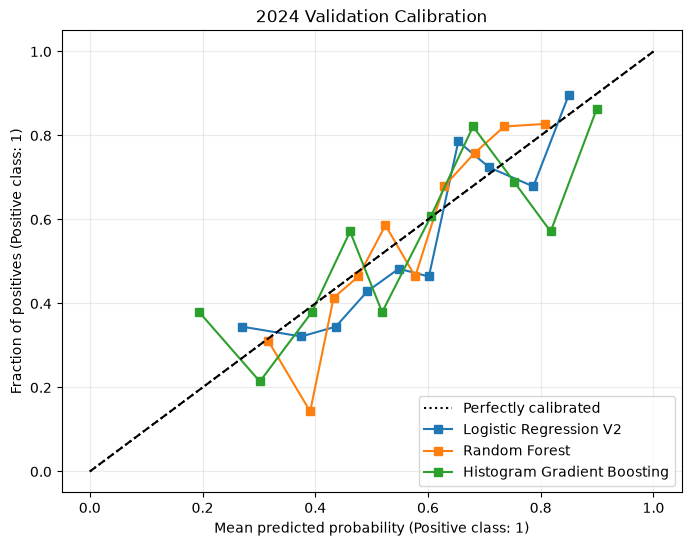

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, probabilities in validation_probabilities.items():
    CalibrationDisplay.from_predictions(
        y_val,
        probabilities,
        n_bins=10,
        strategy='quantile',
        name=model_name,
        ax=ax,
    )
ax.plot(
    [0, 1], [0, 1],
    linestyle='--',
    color='black',
    label='Perfect calibration'
)

ax.set_title('2024 Validation Calibration')
ax.grid(alpha=0.25)
plt.show()

### Comparing V1 and V2 on Shared Games

V1 excludes season-opening games, while V2 retains them. To compare the logistic regression versions on consistent evaluation coverage, both models are scored on the intersection of their 2024 game identifiers. 

On these shared games, V1 achieved 67.29% accuracy and 0.6628 log loss, compared with 65.43% accuracy and 0.6231 log loss for V2. 

The expanded features therefore did not improve this logistic regression comparison. V2 adds season opening coverage and additional information for other model familes, but more features alone do not guarantee better predictions.

The models also have different training-game coverages so this is not full controlled feature-only experiment.

In [15]:
v1_df = pd.read_csv('../data/processed/model_dataset_v1.csv')
v1_artifact = joblib.load('../models/logistic_regression_v1.joblib')

v1_features = v1_artifact['features']
v1_model = v1_artifact['model']

v1_val = v1_df[v1_df['season'] == 2024].copy()

common_game_ids = sorted(
    set(v1_val['game_id'])
    & set(val['game_id'])
)

v1_common = (v1_val[v1_val['game_id'].isin(common_game_ids)]
            .sort_values('game_id'))
v2_common = (val[val['game_id'].isin(common_game_ids)]
            .sort_values('game_id'))


In [16]:
v1_common_prob = v1_model.predict_proba(v1_common[v1_features])[:, 1]

v2_common_prob = fitted_initial_models[
    'Logistic Regression V2'
    ].predict_proba(v2_common[features])[:, 1]

In [17]:
v1_v2_results = pd.DataFrame([
    evaluate_probabilities(
        'Logistic Regression V1',
        v1_common['home_win'],
        v1_common_prob,
        '2024 shared games',
    ),
    evaluate_probabilities(
        'Logistic Regression V2',
        v2_common['home_win'],
        v2_common_prob,
        '2024 shared games',
    ),
])

v1_v2_results



,model,period,accuracy,log_loss,brier_score,roc_auc
0,Logistic Regression V1,2024 shared games,0.672862,0.622797,0.215553,0.727586
1,Logistic Regression V2,2024 shared games,0.654275,0.623086,0.217162,0.709455


### Expanding Temporal Validation and Hyperparameter Search

Each configuration is evaluated on five validation seasons: 2020 through 2024. For each fold, training uses seasons 2010 through the year immediately before the validation season.

This preserves chronological order and measures performance across several football seasons.

The search evaluates 4 logistic regression configurations, 12 Random Forest configurations, and 24 gradient boosting configurations. Within each family, configurations are ranked by mean log loss, with mean Brier score used as the secondary ranking.

Each validation season receives equal weight in the reported mean metrics.

In [18]:
development = df[df['season'].between(MODEL_START_SEASON, 2024)].copy()

CV_SEASONS = [2020, 2021, 2022, 2023, 2024]

In [19]:
def temporal_parameter_search(
        model_name,
        estimator,
        parameter_grid,
        data,
        features,
        target,
        validation_seasons,
):
    search_rows = []

    for parameters in ParameterGrid(parameter_grid):
       fold_metrics = []

       for validation_season in validation_seasons:
           fold_train = data[data['season'] < validation_season]
           fold_val = data[data['season'] == validation_season]

           fold_model = clone(estimator).set_params(**parameters)
           fold_model.fit(fold_train[features], fold_train[target])
           fold_prob = fold_model.predict_proba(fold_val[features])[:, 1]

           fold_metrics.append(
               evaluate_probabilities(
                   model_name=model_name,
                   y_true=fold_val[target],
                   probabilities=fold_prob,
                   evaluation_period=validation_season,
               )
           )

       fold_results = pd.DataFrame(fold_metrics)

       search_rows.append({
           'model': model_name,
           'parameters': parameters,
           'mean_log_loss': fold_results['log_loss'].mean(),
           'std_log_loss': fold_results['log_loss'].std(),
           'mean_brier': fold_results['brier_score'].mean(),
           'mean_accuracy': fold_results['accuracy'].mean(),
           'mean_roc_auc': fold_results['roc_auc'].mean(),
       })

    return (
        pd.DataFrame(search_rows)
        .sort_values(['mean_log_loss', 'mean_brier'], ascending=True,
    ).reset_index(drop=True)
    )


In [20]:
logistic_grid = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0],
}
logistic_search = temporal_parameter_search(
    model_name='Logistic Regression',
    estimator=logistic_model,
    parameter_grid=logistic_grid,
    data=development,
    features=features,
    target=target,
    validation_seasons=CV_SEASONS,
)

logistic_search

,model,parameters,mean_log_loss,std_log_loss,mean_brier,mean_accuracy,mean_roc_auc
0,Logistic Regression,{'classifier__C': 0.01},0.637576,0.023816,0.223272,0.639139,0.688315
1,Logistic Regression,{'classifier__C': 0.1},0.642073,0.025377,0.225195,0.637871,0.682367
2,Logistic Regression,{'classifier__C': 1.0},0.644416,0.026301,0.226206,0.635877,0.678810
3,Logistic Regression,{'classifier__C': 10.0},0.645086,0.026634,0.226502,0.633033,0.678226


In [21]:
random_forest_grid = {
    'model__max_depth': [4, 8, None],
    'model__min_samples_leaf': [5, 15],
    'model__max_features': ['sqrt', 0.5],
}

random_forest_search = temporal_parameter_search(
    model_name='Random Forest',
    estimator=random_forest_model,
    parameter_grid=random_forest_grid,
    data=development,
    features=features,
    target=target,
    validation_seasons=CV_SEASONS,
)

random_forest_search

,model,parameters,mean_log_loss,std_log_loss,mean_brier,mean_accuracy,mean_roc_auc
0,Random Forest,"{'model__max_depth': 8, 'model__max_features':...",0.632565,0.020410,0.221264,0.638941,0.694644
1,Random Forest,"{'model__max_depth': None, 'model__max_feature...",0.633566,0.020764,0.221741,0.636057,0.692986
2,Random Forest,"{'model__max_depth': 8, 'model__max_features':...",0.633824,0.021179,0.221756,0.643796,0.691875
3,Random Forest,"{'model__max_depth': None, 'model__max_feature...",0.634097,0.020120,0.221959,0.638076,0.691899
4,Random Forest,"{'model__max_depth': 8, 'model__max_features':...",0.634279,0.019215,0.222057,0.636057,0.692113
5,Random Forest,"{'model__max_depth': 8, 'model__max_features':...",0.634730,0.022467,0.222077,0.642353,0.689662
6,Random Forest,"{'model__max_depth': None, 'model__max_feature...",0.635156,0.021074,0.222341,0.638805,0.689767
7,Random Forest,"{'model__max_depth': 4, 'model__max_features':...",0.635400,0.018671,0.222405,0.639574,0.691418
8,Random Forest,"{'model__max_depth': 4, 'model__max_features':...",0.635418,0.019625,0.222393,0.638827,0.691682
9,Random Forest,"{'model__max_depth': None, 'model__max_feature...",0.635858,0.023003,0.222433,0.638182,0.689706


In [22]:
gradient_boosting_grid = {
    'learning_rate': [0.03, 0.05, 0.1],
    'max_leaf_nodes': [7, 15],
    'min_samples_leaf': [10, 20],
    'l2_regularization': [0.0, 1.0],
}

gradient_boosting_search = temporal_parameter_search(
    model_name='Histogram Gradient Boosting',
    estimator=gradient_boosting_model,
    parameter_grid=gradient_boosting_grid,
    data=development,
    features=features,
    target=target,
    validation_seasons=CV_SEASONS,
)

gradient_boosting_search.head()

,model,parameters,mean_log_loss,std_log_loss,mean_brier,mean_accuracy,mean_roc_auc
0,Histogram Gradient Boosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.633801,0.028344,0.221851,0.644167,0.690304
1,Histogram Gradient Boosting,"{'l2_regularization': 1.0, 'learning_rate': 0....",0.635564,0.025871,0.222549,0.637448,0.688873
2,Histogram Gradient Boosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.636685,0.029906,0.222984,0.636111,0.687326
3,Histogram Gradient Boosting,"{'l2_regularization': 1.0, 'learning_rate': 0....",0.637575,0.027733,0.223492,0.640359,0.684635
4,Histogram Gradient Boosting,"{'l2_regularization': 1.0, 'learning_rate': 0....",0.640500,0.027493,0.224700,0.635358,0.680942


In [23]:
best_logistic_params = logistic_search.iloc[0]['parameters']
best_random_forest_params = random_forest_search.iloc[0]['parameters']
best_gradient_boosting_params = gradient_boosting_search.iloc[0]['parameters']

tuned_models = {
    'Logistic Regression': (
        clone(logistic_model)
        .set_params(**best_logistic_params)
    ),
    'Random Forest': (
        clone(random_forest_model)
        .set_params(**best_random_forest_params)
    ),
    'Histogram Gradient Boosting': (
        clone(gradient_boosting_model)
        .set_params(**best_gradient_boosting_params)
    ),
}

cv_winners = pd.concat([
    logistic_search.head(1),
    random_forest_search.head(1),
    gradient_boosting_search.head(1),
    ], ignore_index=True).sort_values(['mean_log_loss', 'mean_brier']
    )

cv_winners

,model,parameters,mean_log_loss,std_log_loss,mean_brier,mean_accuracy,mean_roc_auc
1,Random Forest,"{'model__max_depth': 8, 'model__max_features':...",0.632565,0.020410,0.221264,0.638941,0.694644
2,Histogram Gradient Boosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.633801,0.028344,0.221851,0.644167,0.690304
0,Logistic Regression,{'classifier__C': 0.01},0.637576,0.023816,0.223272,0.639139,0.688315


### Out-of-Fold Predictions and Seasonal Stability

The scheduled configuration from each family is refitted for every temporal fold to generate predictions for games outside that fold's training period.

These predictions support pooled performance metrics, calibration plots, and season-by-season comparisons. Pooled metrics weight individual games, so they can differ slightly from the equal-season averages reported during tuning.

Because the same validation seasons were used to select hyperparameters, these are development results rather than an independent evaluation of the entire selection process.

The seasonal results show whether a model's average performance reflets consistent results or a few particularly strong seasons.

In [24]:
def make_temporal_oof_predictions(
        model_name,
        estimator,
        data,
        features,
        target,
        validation_seasons,
):
    prediction_frames = []

    for validation_season in validation_seasons:
        fold_train = data[data['season'] < validation_season]

        fold_val = data[data['season'] == validation_season].copy()

        fold_model = clone(estimator)

        fold_model.fit(fold_train[features], fold_train[target])

        fold_val['predicted_probability'] = (
            fold_model.predict_proba(fold_val[features])[:, 1]
        )

        fold_val['model'] = model_name

        prediction_frames.append(fold_val[[
            'season',
            'week',
            'game_id',
            'home_team',
            'away_team',
            target,
            'predicted_probability',
            'model'
        ]]
        )
    return pd.concat(prediction_frames, ignore_index=True)

In [25]:
oof_predictions = pd.concat([
    make_temporal_oof_predictions(
        model_name,
        estimator,
        development,
        features,
        target,
        CV_SEASONS,
    )
    for model_name, estimator in tuned_models.items()], ignore_index=True)

In [26]:
oof_results = pd.DataFrame([
    evaluate_probabilities(
        model_name=model_name,
        y_true=model_predictions[target],
        probabilities=model_predictions['predicted_probability'],
        evaluation_period='2020-2024 temporal OOF',
    )
    for model_name, model_predictions in oof_predictions.groupby('model')
    ]).sort_values(['log_loss', 'brier_score'])

oof_results

,model,period,accuracy,log_loss,brier_score,roc_auc
2,Random Forest,2020-2024 temporal OOF,0.638889,0.632709,0.221329,0.693950
0,Histogram Gradient Boosting,2020-2024 temporal OOF,0.643875,0.634023,0.221952,0.690770
1,Logistic Regression,2020-2024 temporal OOF,0.638889,0.637858,0.223409,0.687882


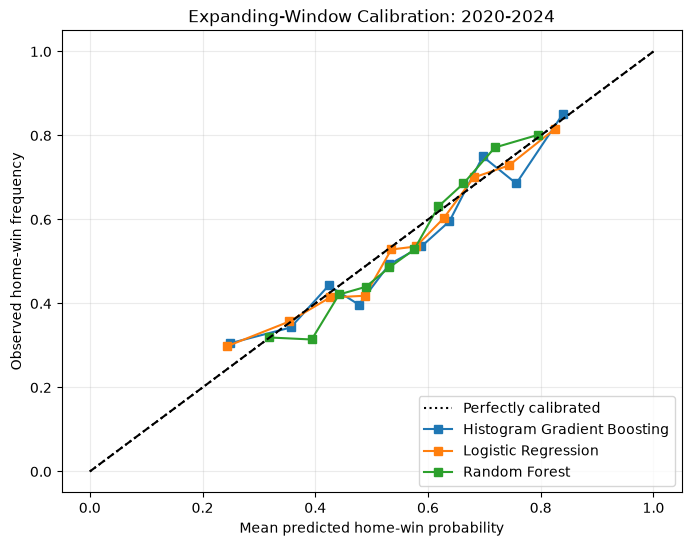

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, model_predictions in oof_predictions.groupby('model'):
    CalibrationDisplay.from_predictions(
        model_predictions[target],
        model_predictions['predicted_probability'],
        n_bins=10,
        strategy='quantile',
        name=model_name,
        ax=ax,
    )
ax.plot(
    [0, 1], [0, 1],
    linestyle='--',
    color='black',
)
ax.set_title('Expanding-Window Calibration: 2020-2024')
ax.set_xlabel("Mean predicted home-win probability")
ax.set_ylabel("Observed home-win frequency")
ax.grid(alpha=0.25)
plt.show()

figure_dir = Path("../reports/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

figure_path = figure_dir / "calibration.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)


In [28]:
season_results = pd.DataFrame([
    evaluate_probabilities(
        model_name=model_name,
        y_true=season_data[target],
        probabilities=season_data['predicted_probability'],
        evaluation_period=season,
    )
    for (model_name, season), season_data
    in oof_predictions.groupby(['model', 'season'])
])
season_results.sort_values(
    ['period', 'log_loss']
    )

,model,period,accuracy,log_loss,brier_score,roc_auc
0,Histogram Gradient Boosting,2020,0.675373,0.612270,0.212192,0.736077
5,Logistic Regression,2020,0.660448,0.613386,0.211492,0.737859
10,Random Forest,2020,0.645522,0.620705,0.215898,0.736912
11,Random Forest,2021,0.602113,0.645952,0.227685,0.675406
1,Histogram Gradient Boosting,2021,0.637324,0.655440,0.230572,0.671731
6,Logistic Regression,2021,0.619718,0.662672,0.234142,0.659566
12,Random Forest,2022,0.638298,0.627692,0.219049,0.691906
7,Logistic Regression,2022,0.641844,0.634085,0.221960,0.682275
2,Histogram Gradient Boosting,2022,0.606383,0.644654,0.226413,0.667828
13,Random Forest,2023,0.610526,0.659899,0.234095,0.629383


### Final Model Decision

The selected model is histogram gradient boosting with the following configuration:

* Learning rate: 0.03
* Maximum iterations: 300
* Maximum leaf nodes: 7
* Minimum samples per leaf: 20
* L2 regularization: 0.0
* Early stopping: disabled
* Random state: 42

The tuned models produced the following mean temporal validation results:

| Model                       | Accuracy | Log loss | Brier score |
| --------------------------- | -------: | -------: | ----------: |
| Logistic regression         |   63.91% |   0.6376 |      0.2233 |
| Random Forest               |   63.89% |   0.6326 |      0.2213 |
| Histogram gradient boosting |   64.42% |   0.6338 |      0.2219 |

Gradient boosting had the highest mean accuracy and the highest accuracy in three of the five validation seasons.

Random Forest had better mean log loss and Brier score. Selecting gradient boosting therefore prioritizes a small winner prediction accuracy advantage over the strongest probability metrics. It does not establish gradient boosting as the best model on every objective.

The selected configuration is fixed before the final model's 2025 evaluation. However, earlier notebooks already reported 2025 benchmark results, so that season cannot be described as never previously examined. 

### Interpreting the Selected Model with Permutation Importance

For interpretation, a separate copy of the selected model is trained on 2010-2023 evaluated on 2024. 

Permutation importance measures how much predictive performance deteriorates when one feature is shuffled. With negative log loss as the scoring function, a larger positive importance corresponds to a larger increase in log loss after shuffling.

The saved results rank home and away Elo, quarterback EPA, and several efficiency features among the leading inputs.

These values describe model reliance on this evaluation set, not causal effects. Correlated features can share predictive information, reducing the apparent importance of any individual feature.

In [29]:
chosen_model_name = 'Histogram Gradient Boosting'

chosen_model = clone(tuned_models[chosen_model_name])

explanation_model = clone(chosen_model)
explanation_model.fit(
    train[features],
    train[target],
)
importance = permutation_importance(
    explanation_model,
    X_val,
    y_val,
    scoring='neg_log_loss',
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance_df = pd.DataFrame({
    'feature': features,
    'importance': importance.importances_mean,
    'std': importance.importances_std,
}).sort_values('importance', ascending=False)
importance_df.head(20)

,feature,importance,std
24,home_pregame_elo,0.013122,0.002956
60,away_pregame_elo,0.008011,0.003398
69,away_pregame_qb_epa,0.007767,0.003918
33,home_pregame_qb_epa,0.006614,0.004683
4,home_pregame_def_epa_allowed_blended,0.005948,0.004013
34,home_pregame_qb_epa_last5,0.005745,0.002123
38,away_pregame_pass_epa_blended,0.005591,0.004986
36,away_pregame_off_epa_blended,0.005340,0.003624
15,home_rush_epa_last5,0.004393,0.001765
6,home_off_epa_last3,0.004258,0.003868


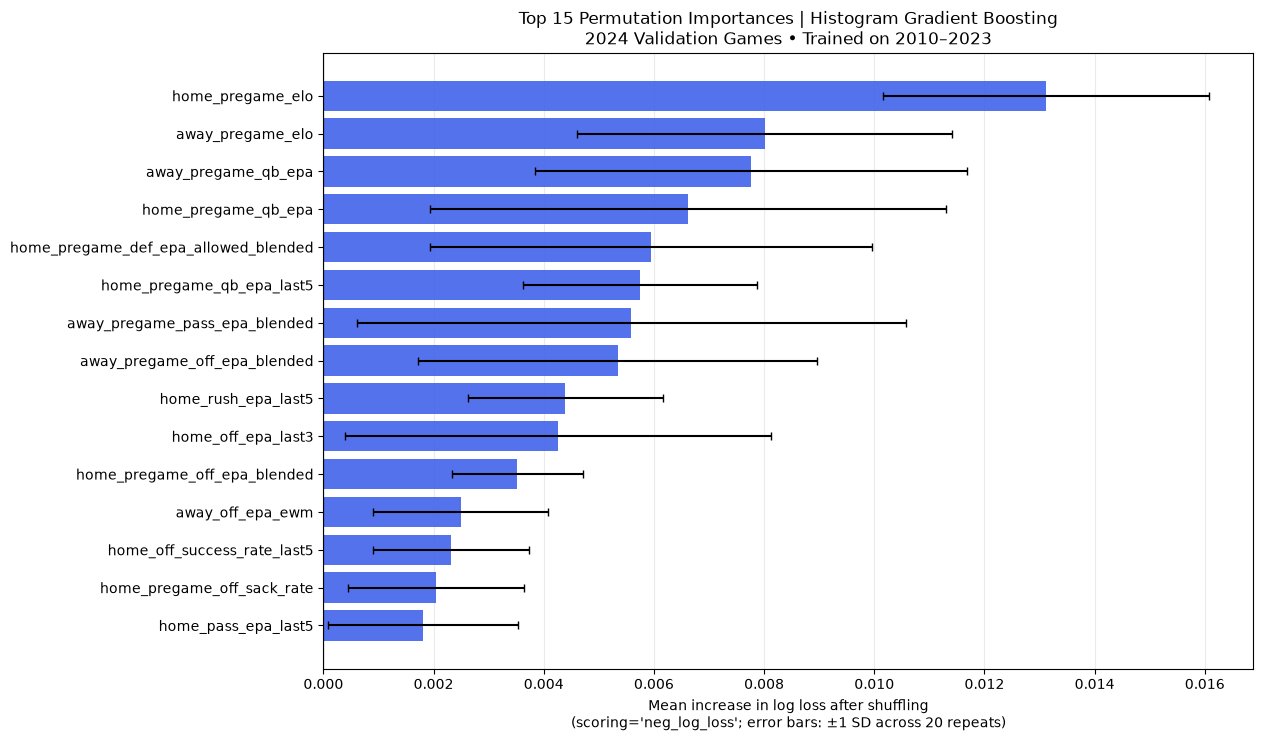

In [30]:
top_importance = (
    importance_df
    .nlargest(15, "importance")
    .sort_values("importance")
)

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(
    top_importance["feature"],
    top_importance["importance"],
    xerr=top_importance["std"],
    color="#4263EB",
    alpha=0.9,
    capsize=3,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(
    "Top 15 Permutation Importances | Histogram Gradient Boosting\n"
    "2024 Validation Games • Trained on 2010–2023"
)
ax.set_xlabel(
    "Mean increase in log loss after shuffling\n"
    "(scoring='neg_log_loss'; error bars: ±1 SD across 20 repeats)"
)

ax.set_ylabel("")
ax.set_axisbelow(True)
ax.grid(axis="x", alpha=0.25)

plt.show()

figure_dir = Path("../reports/figures")
figure_dir.mkdir(parents=True, exist_ok=True)

figure_path = figure_dir / "permutation_importance.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)


### Inspecting Confident Errors and Uncertain Games

The error analysis identifies incorrect predictions with the highest assigned winner probabilities, alongside games predicted close to 50-50. 

Examples include Green Bay losing to Chicago after receiving a 82.95% predicted win probability and Houston losing to Tennessee after receiving 82.13%. 

These cases help identify where the model can be confidently wrong. The prediction table alone does not establish whether an error resulted from injuries, lineup changes, unusual game events, or ordinary outcome uncertainty.

In [31]:
val_error_analysis = val[[
    'season',
    'week',
    'gameday',
    'game_id',
    'home_team',
    'away_team',
    'home_win',
]].copy()

val_error_analysis['home_win_probability'] = (
    explanation_model.predict_proba(X_val)[:, 1]
)
val_error_analysis['predicted_home_win'] = (
    val_error_analysis['home_win_probability'] >= 0.5
).astype(int)

val_error_analysis['predicted_winner'] = np.where(
    val_error_analysis['predicted_home_win'].eq(1),
    val_error_analysis['home_team'],
    val_error_analysis['away_team'],
)

val_error_analysis['actual_winner'] = np.where(
    val_error_analysis['home_win'].eq(1),
    val_error_analysis['home_team'],
    val_error_analysis['away_team'],
)

val_error_analysis['confidence'] = np.maximum(
    val_error_analysis['home_win_probability'],
    1 - val_error_analysis['home_win_probability']
)

val_error_analysis['correct'] = (
    val_error_analysis['predicted_home_win']
    == val_error_analysis['home_win']
)

In [32]:
confident_errors = (
    val_error_analysis[
        ~val_error_analysis['correct']
    ]
    .sort_values('confidence', ascending=False)
)
confident_errors.head(3)

,season,week,gameday,game_id,home_team,away_team,home_win,home_win_probability,predicted_home_win,predicted_winner,actual_winner,confidence,correct
4308,2024,18,2025-01-05,2024_18_CHI_GB,GB,CHI,0,0.829455,1,GB,CHI,0.829455,False
4225,2024,12,2024-11-24,2024_12_TEN_HOU,HOU,TEN,0,0.821332,1,HOU,TEN,0.821332,False
4158,2024,8,2024-10-27,2024_08_BAL_CLE,CLE,BAL,1,0.183039,0,BAL,CLE,0.816961,False


In [33]:
uncertain_games = (
    val_error_analysis
    .assign(
        distance_from_50=lambda x:
        abs(x['home_win_probability'] - 0.5)
    )
    .sort_values('distance_from_50')
)
uncertain_games.head(3)

,season,week,gameday,game_id,home_team,away_team,home_win,home_win_probability,predicted_home_win,predicted_winner,actual_winner,confidence,correct,distance_from_50
4215,2024,12,2024-11-24,2024_12_ARI_SEA,SEA,ARI,1,0.500268,1,SEA,SEA,0.500268,True,0.000268
4201,2024,11,2024-11-17,2024_11_ATL_DEN,DEN,ATL,1,0.496827,0,ATL,DEN,0.503173,False,0.003173
4111,2024,4,2024-09-30,2024_04_TEN_MIA,MIA,TEN,0,0.504098,1,MIA,TEN,0.504098,False,0.004098


## Final Refit and 2025 Evaluation

The selected model is refitted using all modeling seasons from 2010–2024. Its architecture and hyperparameters remain unchanged.

The model is then evaluated on 284 non-tied games from 2025. Team and quarterback features for each game use historical performance, including earlier completed games within 2025, while the fitted model parameters remain fixed.

The saved results are:

| Metric      | Result |
| ----------- | -----: |
| Accuracy    | 65.85% |
| Log loss    | 0.6413 |
| Brier score | 0.2244 |
| ROC-AUC     | 0.6865 |

These are historical test results, not live predictions recorded before kickoff. Their interpretation should also acknowledge the earlier inspection of 2025 benchmark performance.


In [34]:
final_train = df[
    df['season'].between(MODEL_START_SEASON, 2024)
].copy()

final_test = df[df['season'] == TEST_SEASON].copy()

final_model = clone(chosen_model)
final_model.fit(final_train[features], final_train[target])

,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.03
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",300
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",7
,"early_stopping early_stopping: 'auto' or bool, default='auto'If 'auto', early stopping is enabled if the sample size is larger than10000 or if `X_val` and `y_val` are passed to `fit`. If True, early stoppingis enabled, otherwise early stopping is disabled... versionadded:: 0.23",False
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255


In [35]:
final_test_prob = final_model.predict_proba(final_test[features])[:, 1]

final_test_result = pd.DataFrame([
    evaluate_probabilities(
        model_name=chosen_model_name,
        y_true=final_test[target],
        probabilities=final_test_prob,
        evaluation_period='2025 final test',
    )
])

final_test_result

,model,period,accuracy,log_loss,brier_score,roc_auc
0,Histogram Gradient Boosting,2025 final test,0.658451,0.641331,0.224411,0.686453


In [36]:
final_test_predictions = final_test[[
    'season',
    'week',
    'gameday',
    'game_id',
    'home_team',
    'away_team',
    'home_win',
]].copy()

final_test_predictions['home_win_probability'] = final_test_prob
final_test_predictions['away_win_probability'] = (1 - final_test_prob)

final_test_predictions['predicted_winner'] = np.where(
    final_test_prob >= 0.5,
    final_test_predictions['home_team'],
    final_test_predictions['away_team']
)
final_test_predictions['actual_winner'] = np.where(
    final_test_predictions['home_win'].eq(1),
    final_test_predictions['home_team'],
    final_test_predictions['away_team'],
)
final_test_predictions['correct'] = (
    final_test_predictions['predicted_winner']
    == final_test_predictions['actual_winner']
)

### Saving the Final Evaluation Model

The fitted model is saved as `models/final_nfl_win_probability_model.joblib`, together with its ordered feature list, hyperparameters, target definition, training period, and decision threshold.

The positive-class probability represents a home win. Away-win probability is calculated as its complement; the model does not estimate a separate tie probability.

This artifact was trained through 2024 and supports the reported 2025 evaluation. A production model retrained through 2025 is a separate artifact used for subsequent predictions.

The next stage connects the selected modeling approach to reusable feature-building, weekly prediction, and results-tracking scripts.

In [37]:
model_path = Path('../models/final_nfl_win_probability_model.joblib')

artifact = {
    'model': final_model,
    'model_name': chosen_model_name,
    'model_parameters': final_model.get_params(),
    'features': features,
    'target': target,
    'positive_class': 'home_win',
    'decision_threshold': 0.5,
    'training_seasons': '2010-2024',
    'test_season': 2025,
    'dataset_version': 'model_dataset_v2',
    'probability_definition': (
        'predict_proba(X)[:, 1] is the probability that the home team wins')
}
joblib.dump(artifact, model_path)

print(f"Saved final model to: {model_path.resolve()}")

Saved final model to: C:\Coding Projects\NFL-2026-Machine-Learning-Project\models\final_nfl_win_probability_model.joblib
